# BCGGAN: aplicacion de un modelo entrenado

Este notebook carga solo EEG contaminado y un checkpoint BCGGAN previamente entrenado. Aplica el generador BCG-a-EEG limpio y muestra una comparacion temporal. No calcula metricas: quedan pendientes de definir en el proyecto.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mne
import numpy as np

START_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT = next((path for path in (START_DIRECTORY, *START_DIRECTORY.parents) if (path / 'src').is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate the repository root containing src/.')
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from functions.bcggan import BCGGANTrainer

In [12]:
EEG_ROOT = PROJECT_ROOT / 'data/raw/Dataset1/Simultaneous_EEG_fMRI/BIDS_dataset_EEG'
SUBJECT = 'sub-001'
TASK = 'fmrirestingec'
CHECKPOINT = PROJECT_ROOT / 'data/models/bcggan_primer_entrenamiento_best.pt'
CHANNEL_INDEX = 6
START_SECONDS = 60
DISPLAY_SECONDS = 10.0
WINDOW_SECONDS = 5.0
BATCH_SIZE = 32

In [5]:
eeg_path = EEG_ROOT / SUBJECT / 'eeg' / f'{SUBJECT}_task-{TASK}_eeg.set'
if not eeg_path.is_file():
    raise FileNotFoundError(f'EEGLAB header not found: {eeg_path}')
if not CHECKPOINT.is_file():
    raise FileNotFoundError(f'BCGGAN checkpoint not found: {CHECKPOINT}')

raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose='ERROR')
corrupted = raw.get_data()
fs = float(raw.info['sfreq'])
trainer = BCGGANTrainer.load_checkpoint(CHECKPOINT)
print(f'EEG: {eeg_path.name}; shape: {corrupted.shape}; fs: {fs} Hz')
window_samples = int(round(WINDOW_SECONDS * fs))
complete_windows, tail_samples = divmod(corrupted.shape[1], window_samples)
print(f'Checkpoint: {CHECKPOINT.name}; completed epochs: {trainer.completed_epochs}')
print(f'Inference: {complete_windows} consecutive windows of {WINDOW_SECONDS:g} s ({window_samples} samples) per EEG channel.')
if tail_samples:
    print(f'Final residual: {tail_samples / fs:.3f} s; it is retained because it is shorter than one model window.')

EEG: sub-001_task-fmrirestingec_eeg.set; shape: (33, 639320); fs: 1000.0 Hz
Checkpoint: bcggan_primer_entrenamiento_best.pt; completed epochs: 16
Inference: 127 consecutive windows of 5 s (5000 samples) per EEG channel.
Final residual: 4.320 s; it is retained because it is shorter than one model window.


In [6]:
mne.viz.set_browser_backend('qt')
raw.plot(
    n_channels=20,
    duration=10,
    show_scrollbars=True,
    block=True,
)

Using qt as 2D backend.
Channels marked as bad:
none


In [7]:
if trainer.config.channels == 1:
    auxiliary_tokens = ('ECG', 'EKG', 'VREF', 'TRIG', 'STI', 'MISC', 'RESP', 'EOG', 'EMG', 'AUX')
    eeg_indices = [index for index, name in enumerate(raw.ch_names) if not any(token in name.upper() for token in auxiliary_tokens)]
    cleaned = corrupted.copy()
    cleaned[eeg_indices] = trainer.clean_recording(corrupted[eeg_indices], fs, window_s=WINDOW_SECONDS, stride_s=WINDOW_SECONDS, batch_size=BATCH_SIZE)
else:
    cleaned = trainer.clean_recording(corrupted, fs, window_s=WINDOW_SECONDS, stride_s=WINDOW_SECONDS, batch_size=BATCH_SIZE)
print('The cleaned full recording is the chronological concatenation of the inferred 5-s windows.')
# TODO: incorporar metricas de evaluacion del conjunto de test cuando esten definidas.

The cleaned full recording is the chronological concatenation of the inferred 5-s windows.


## Visualizacion despues de BCGGAN

El resultado se inserta en una copia de `Raw` para utilizar el mismo visor interactivo de MNE que AAS.

In [8]:
raw_clean = raw.copy()
raw_clean._data = cleaned.copy()
raw_clean.plot(
    n_channels=20,
    duration=10,
    show_scrollbars=True,
    block=True,
)

Channels marked as bad:
none


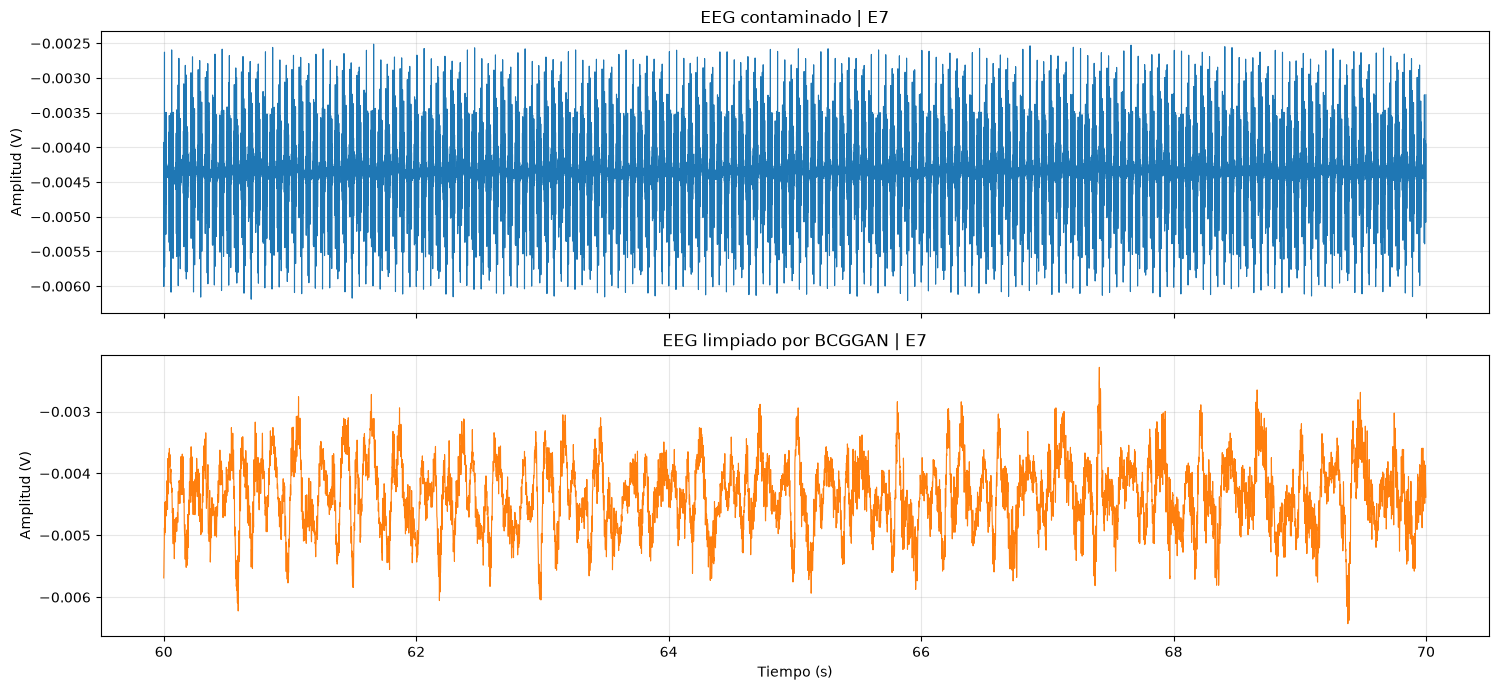

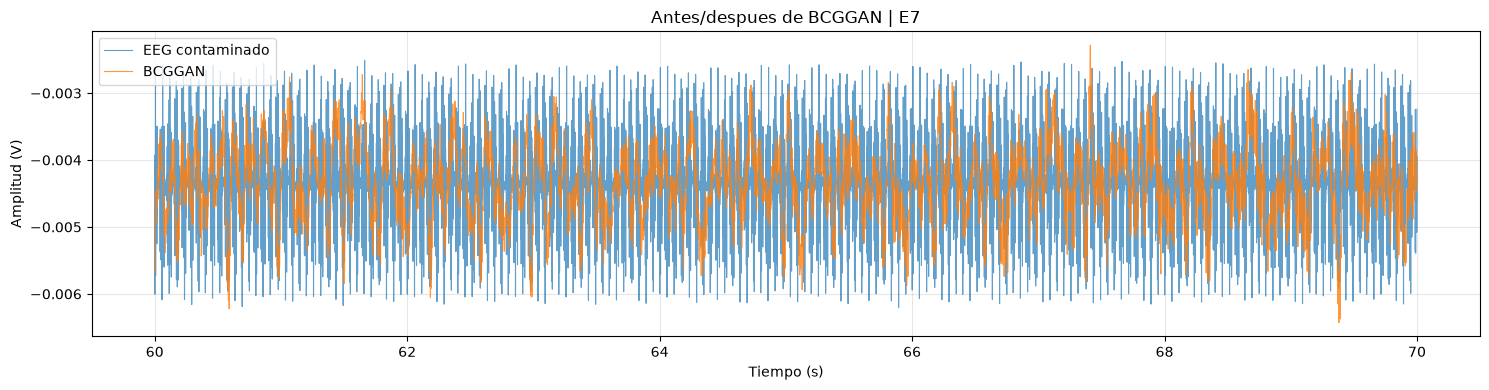

In [13]:
start = int(round(START_SECONDS * fs))
stop = min(start + int(round(DISPLAY_SECONDS * fs)), corrupted.shape[1])
time = np.arange(start, stop) / fs
channel_name = raw.ch_names[CHANNEL_INDEX]

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
axes[0].plot(time, corrupted[CHANNEL_INDEX, start:stop], color='tab:blue', lw=0.8)
axes[0].set_title(f'EEG contaminado | {channel_name}')
axes[1].plot(time, cleaned[CHANNEL_INDEX, start:stop], color='tab:orange', lw=0.8)
axes[1].set_title(f'EEG limpiado por BCGGAN | {channel_name}')
for axis in axes:
    axis.set_ylabel('Amplitud (V)')
    axis.grid(alpha=0.3)
axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(15, 4))
plt.plot(time, corrupted[CHANNEL_INDEX, start:stop], label='EEG contaminado', alpha=0.7, lw=0.8)
plt.plot(time, cleaned[CHANNEL_INDEX, start:stop], label='BCGGAN', alpha=0.8, lw=0.8)
plt.title(f'Antes/despues de BCGGAN | {channel_name}')
plt.xlabel('Tiempo (s)'); plt.ylabel('Amplitud (V)')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()